In [31]:
from kg.query import query_kg, query_kg_endpoint, get_triples_from_response
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import os

In [32]:
from utils.kg_functions import load_json, extract_ids_with_prefix, convert_QID_yagoID
from utils.kg_functions import combine_lists_from_dict, get_yago_direct_neighbors, sparql_to_triples_with_main_entity
from utils.kg_functions import parallel_process_nodes, extract_ids_with_prefix, parallel_convert_QID_yagoID
from utils.helper_functions import decode_underscored_unicode
from utils.prompts import gen_qa_prompt

# from utils.subgraph_functions import create_graph_from_triples, build_minimal_subgraph_Steiner, largest_connected_subgraph
# from utils.subgraph_functions import plot_graph_with_simplified_labels, get_interesting_entities, filter_triples_by_predicates
from utils.subgraph_functions import (create_graph_from_triples, build_minimal_subgraph_Steiner, plot_full_graph,
                                      largest_connected_subgraph, edges_to_triples, plot_graph_with_simplified_labels,
                                      get_interesting_entities, filter_triples_by_predicates, prune_triples)
from utils.wiki_ner import extract_entities_to_json

In [3]:

exclude_props = ['knowsLanguage', 'location', 'image', 'about', 'comment', 'gtin', 'url', 'label', 
                 'postalCode', 'isbn', 'sameAs', 'mainEntityOfPage', 'leiCode', 'type', 'dateCreated', 
                 'unemploymentRate', 'length', 'description', 'iswcCode', 'iataCode', 'logo', 'alternateName', 
                 'geo', 'subclassOf', 'icaoCode', 'humanDevelopmentIndex', 'sameAs', 'dateCreated', 
                 'startDate', 'endDate', 'follows', 'superEvent']

In [4]:
def process_qid(QID, entities):
    try:
        # logging.info(f"Processing QID: {QID}")
        
        interesting_entities = get_interesting_entities(QID, entities)
        results = parallel_process_nodes(interesting_entities)
        comb_list_large = combine_lists_from_dict(results)
        comb_list = filter_triples_by_predicates(comb_list_large, exclude_props)
        graph = create_graph_from_triples(comb_list)

        subgraph_Steiner = build_minimal_subgraph_Steiner(graph, interesting_entities)
        subgraph_Steiner_largest_connected = largest_connected_subgraph(subgraph_Steiner)

        subgraph_Steiner_triples = edges_to_triples(subgraph_Steiner)
        subgraph_Steiner_largest_connected_triples = edges_to_triples(subgraph_Steiner_largest_connected)

        result = {
            'subgraph_Steiner': subgraph_Steiner_triples,
            'subgraph_Steiner_length': len(subgraph_Steiner_triples),
            'subgraph_Steiner_largest_connected': subgraph_Steiner_largest_connected_triples,
            'subgraph_Steiner_largest_connected_length': len(subgraph_Steiner_largest_connected_triples)
        }

        # logging.info(f"Finished processing QID: {QID}")
        return QID, result, interesting_entities, comb_list_large

    except Exception as e:
        print(f"Error processing QID {QID}: {e}")
        return QID, None

In [157]:
subg = [["http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Argentina"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/director", "http://yago-knowledge.org/resource/Lucas_Demare"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Amelia_Bence"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Francisco_Petrone"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/\u00c1ngel_Maga\u00f1a"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Enrique_Mui\u00f1o"], ["http://yago-knowledge.org/resource/El_Hombre_Que_Naci\u00f3_Dos_Veces_Q5825266", "http://schema.org/musicBy", "http://yago-knowledge.org/resource/Homero_Manzi"], ["http://yago-knowledge.org/resource/El_Hombre_Que_Naci\u00f3_Dos_Veces_Q5825266", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola"], ["http://yago-knowledge.org/resource/Ulyses_Petit_de_Murat", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"],  ["http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_", "http://schema.org/author", "http://yago-knowledge.org/resource/Leopoldo_Lugones"], ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://yago-knowledge.org/resource/notableWork", "http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_"]]

In [7]:


def plot_graph_with_simplified_labels(graph, title="Graph Visualization", figsize=(10, 10), 
                                      layout_type=None, interesting_nodes=None, node_type_colors=None):
    """
    Plot a graph with improved aesthetics.
    
    Parameters:
    - graph: NetworkX graph
    - title: Title for the plot
    - figsize: Tuple specifying figure size
    - layout_type: Explicit layout choice ("spring", "shell", "circular", "kamada_kawai", "spectral")
    - interesting_nodes: List of nodes to highlight with a different color
    - node_type_colors: Dictionary mapping node types to specific colors
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()

    # Determine layout
    if layout_type == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        pos = nx.shell_layout(graph)
    elif layout_type == "circular":
        pos = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        pos = nx.spectral_layout(graph)
    else:
        if num_nodes < 10:
            pos = nx.shell_layout(graph)
        elif num_edges > num_nodes * 2:
            pos = nx.circular_layout(graph)
        elif nx.is_tree(graph):
            pos = nx.kamada_kawai_layout(graph)
        else:
            pos = nx.spring_layout(graph, seed=42)

    plt.figure(figsize=figsize)
    
    # Simplify node labels
    node_labels = {node: decode_underscored_unicode(node.split('/')[-1]) for node in graph.nodes()}

    # Simplify edge labels
    edge_labels = {
        (u, v): decode_underscored_unicode(data['relation'].split('/')[-1])
        for u, v, data in graph.edges(data=True)
    }

    # Assign node colors based on type
    default_color = "#D3D3D3"  # Light gray for default nodes
    highlight_color = "#FF5733"  # Red for interesting nodes
    node_colors = []

    for node in graph.nodes():
        if interesting_nodes and node in interesting_nodes:
            node_colors.append(highlight_color)
        elif node_type_colors and node in node_type_colors:
            node_colors.append(node_type_colors[node])
        else:
            node_colors.append(default_color)

    # Draw graph
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=2500, edgecolors='black')
    nx.draw_networkx_edges(graph, pos, alpha=0.6, width=2, edge_color="gray", arrows=True)
    nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=10, font_weight="bold") #font_family="Arial", 

    # Draw edge labels with curved edges
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8) #font_family="Arial", 

    # Set title
    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


In [167]:
import networkx as nx
import matplotlib.pyplot as plt

# def decode_underscored_unicode(text):
#     """Decodes text replacing underscores with spaces (assuming no special Unicode processing)."""
#     return text.replace('_', ' ')

def plot_graph_with_simplified_labels(graph, title="Graph Visualization", figsize=(10, 10), 
                                      layout_type=None, interesting_triples=None, node_type_colors=None,
                                      highlight_node_color="#1E90FF",  # Default: DodgerBlue
                                      highlight_edge_color="#4682B4",  # Default: SteelBlue
                                      default_node_color="#D3D3D3",  # Default: LightGray
                                      default_edge_color="gray",  # Default: Gray
                                      highlight_text_color="white",  # Default: White for highlighted nodes
                                      default_text_color="black",
                                      saveLoc = '/home/ubuntu/preetam_experiments/plots/multipleQues_samegraph',
                                      saveFileName = 'graphPlot'):  # Default: Black for non-highlighted nodes
    """
    Plot a graph with improved aesthetics, highlighting specific triples.

    Parameters:
    - graph: NetworkX graph
    - title: Title for the plot
    - figsize: Tuple specifying figure size
    - layout_type: Explicit layout choice ("spring", "shell", "circular", "kamada_kawai", "spectral")
    - interesting_triples: List of (subject, predicate, object) triples to highlight
    - node_type_colors: Dictionary mapping node types to specific colors
    - highlight_node_color: Color for highlighted nodes (default: DodgerBlue)
    - highlight_edge_color: Color for highlighted edges (default: SteelBlue)
    - default_node_color: Color for regular nodes (default: LightGray)
    - default_edge_color: Color for regular edges (default: Gray)
    - highlight_text_color: Text color for highlighted nodes (default: White)
    - default_text_color: Text color for non-highlighted nodes (default: Black)
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()

    # Determine layout
    if layout_type == "spring":
        pos = nx.spring_layout(graph, seed=42)
    elif layout_type == "shell":
        pos = nx.shell_layout(graph)
    elif layout_type == "circular":
        pos = nx.circular_layout(graph)
    elif layout_type == "kamada_kawai":
        pos = nx.kamada_kawai_layout(graph)
    elif layout_type == "spectral":
        pos = nx.spectral_layout(graph)
    else:
        if num_nodes < 10:
            pos = nx.shell_layout(graph)
        elif num_edges > num_nodes * 2:
            pos = nx.circular_layout(graph)
        elif nx.is_tree(graph):
            pos = nx.kamada_kawai_layout(graph)
        else:
            pos = nx.spring_layout(graph, seed=12)

    plt.figure(figsize=figsize)
    
    # Simplify node labels
    node_labels = {node: decode_underscored_unicode(node.split('/')[-1]).replace(' ', '\n') for node in graph.nodes()}

    # Simplify edge labels and determine highlight edges
    edge_labels = {}
    highlighted_edges = set()
    
    if interesting_triples:
        interesting_triples_set = {(s, o) for s, p, o in interesting_triples}  # Convert to set for fast lookup
    else:
        interesting_triples_set = set()
    
    for u, v, data in graph.edges(data=True):
        relation = decode_underscored_unicode(data['relation'].split('/')[-1])
        edge_labels[(u, v)] = relation
        if (u, v) in interesting_triples_set:
            highlighted_edges.add((u, v))

    # Assign node colors based on type and whether they appear in highlighted triples
    node_colors = {}
    node_text_colors = {}
    
    for node in graph.nodes():
        if any(node in (s, o) for s, p, o in interesting_triples or []):  # Check if node is part of a triple
            node_colors[node] = highlight_node_color
            node_text_colors[node] = highlight_text_color
        elif node_type_colors and node in node_type_colors:
            node_colors[node] = node_type_colors[node]
            node_text_colors[node] = default_text_color
        else:
            node_colors[node] = default_node_color
            node_text_colors[node] = default_text_color

    # Draw graph with differentiation for highlighted triples
    nx.draw_networkx_nodes(graph, pos, node_color=[node_colors[n] for n in graph.nodes()], 
                           node_size=4000, edgecolors='black')
    
    # Default edges
    nx.draw_networkx_edges(graph, pos, edgelist=[(u, v) for u, v in graph.edges() if (u, v) not in highlighted_edges],
                           alpha=0.6, width=2, edge_color=default_edge_color, arrows=True)
    
    # Highlighted edges
    nx.draw_networkx_edges(graph, pos, edgelist=list(highlighted_edges), 
                           alpha=1.0, width=3, edge_color=highlight_edge_color, arrows=True)

    # Draw labels manually with different colors for highlighted and default nodes
    for node, label in node_labels.items():
        font_color = node_text_colors[node]
        plt.text(pos[node][0], pos[node][1], label, fontsize=10, fontweight="bold",
                 color=font_color, ha='center', va='center')

    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8)

    # Set title
    # plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    # plt.show()
    plt.savefig(f"{saveLoc}/{saveFileName}.pdf",dpi=300, bbox_inches='tight')


In [156]:

interesting_set1 = [
  ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebastián_Chiola"],
  ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Amelia_Bence"],
  ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Francisco_Petrone"],
  ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Ángel_Magaña"],
  ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Enrique_Muiño"]
]



In [159]:
related_qa_pairs = [
    {
        "question": "Who directed The Gaucho War?",
        "answer": "http://yago-knowledge.org/resource/Lucas_Demare",
        "supporting triples": [
            ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/director", "http://yago-knowledge.org/resource/Lucas_Demare"]
        ]
    },
    {
        "question": "Which composer wrote the music for a film featuring the same Argentinian actor who appears in The Gaucho War?",
        "answer": "http://yago-knowledge.org/resource/Homero_Manzi",
        "supporting triples": [
            ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebastián_Chiola"],
            ["http://yago-knowledge.org/resource/El_Hombre_Que_Nació_Dos_Veces_Q5825266", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebastián_Chiola"],
            ["http://yago-knowledge.org/resource/El_Hombre_Que_Nació_Dos_Veces_Q5825266", "http://schema.org/musicBy", "http://yago-knowledge.org/resource/Homero_Manzi"]
        ]
    },
    {
        "question": "Name the actor who played in both The Gaucho War and El Hombre Que Nació Dos Veces.",
        "answer": "http://yago-knowledge.org/resource/Sebastián_Chiola",
        "supporting triples": [
            ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebastián_Chiola"],
            ["http://yago-knowledge.org/resource/El_Hombre_Que_Nació_Dos_Veces_Q5825266", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebastián_Chiola"]
        ]
    },
    {
        "question": "Who authored the novel La Guerra Gaucha, and what notable work did they write?",
        "answer": "http://yago-knowledge.org/resource/Leopoldo_Lugones",
        "supporting triples": [
            ["http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_", "http://schema.org/author", "http://yago-knowledge.org/resource/Leopoldo_Lugones"],
            ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://yago-knowledge.org/resource/notableWork", "http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_"]
        ]
    }
]

In [161]:
related_qa_pairs[0]['supporting triples']

[['http://yago-knowledge.org/resource/The_Gaucho_War',
  'http://schema.org/director',
  'http://yago-knowledge.org/resource/Lucas_Demare']]

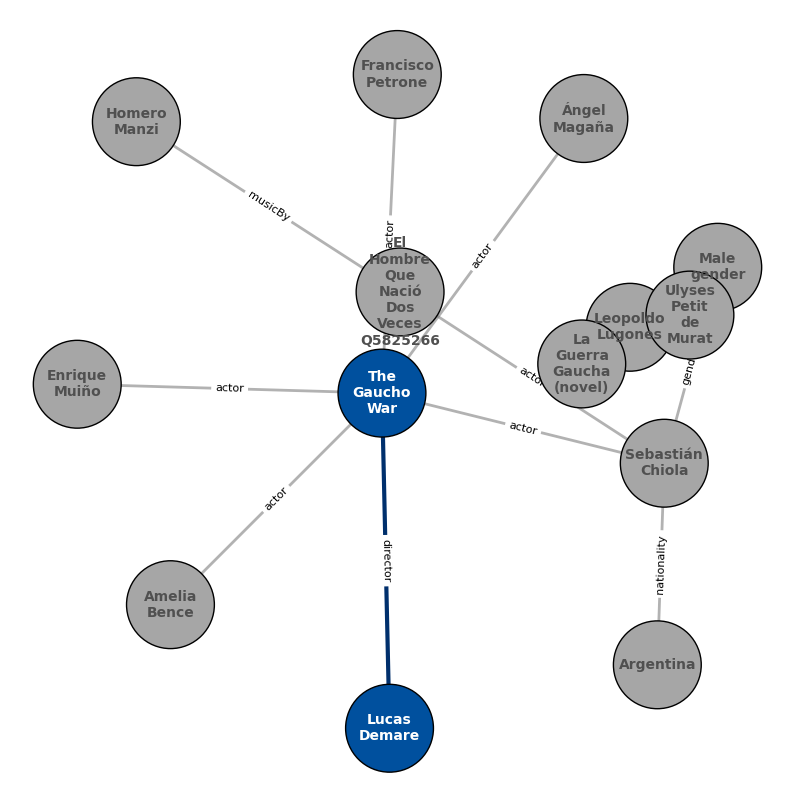

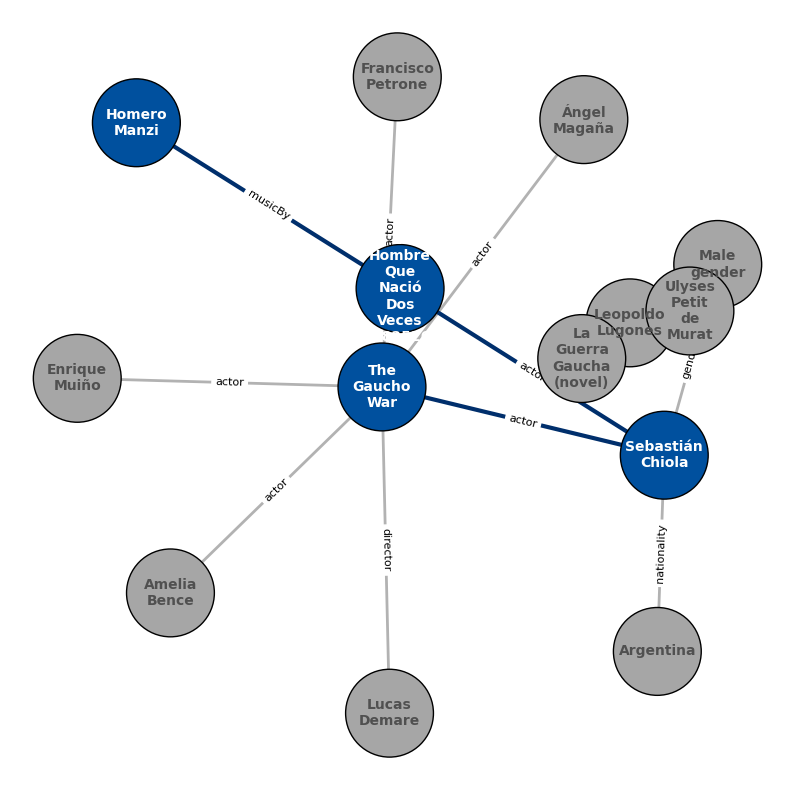

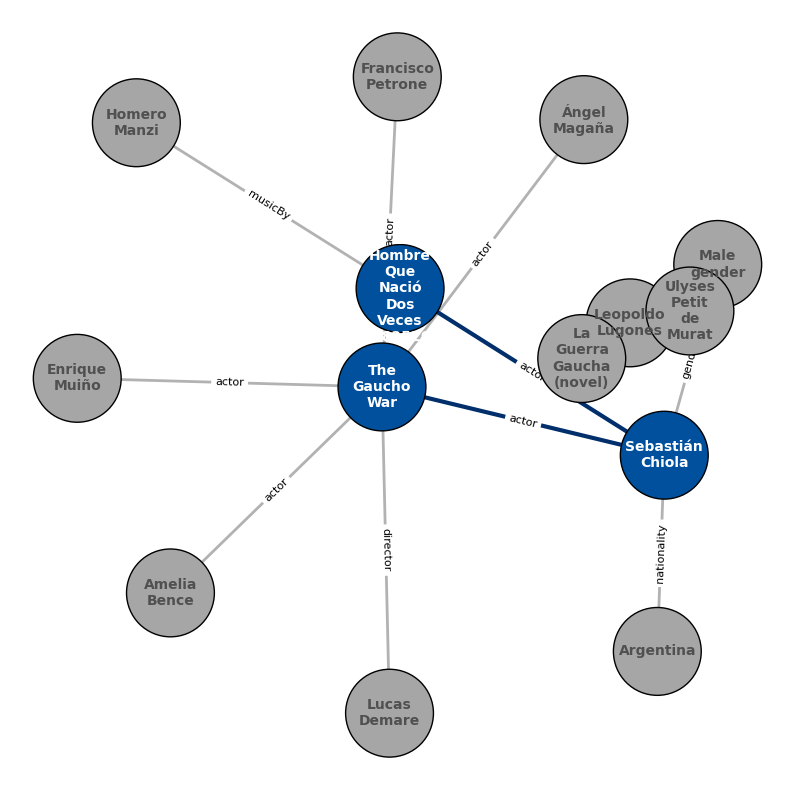

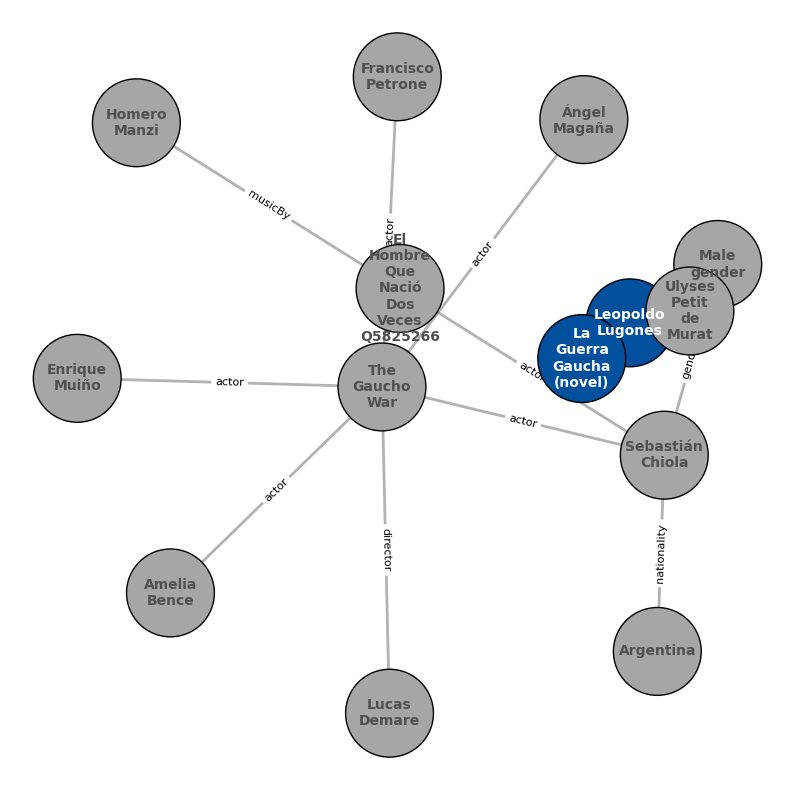

In [171]:
#shuffle the subgraph
import random
random.shuffle(subg)
#fix the seed
random.seed(7)

layout_type = 'spring'
g = create_graph_from_triples(subg)
plot_graph_with_simplified_labels(g, 
                                  layout_type=layout_type, 
                                  interesting_triples=related_qa_pairs[0]['supporting triples'], 
                                  highlight_node_color="#00509E",  
                                  highlight_edge_color="#002F6C", 
                                  default_node_color="#A6A6A6",   
                                  default_edge_color="#7F7F7F",   
                                  highlight_text_color="white",#000000",    
                                  default_text_color="#505050",
                                  saveFileName="q1_plot")  

plot_graph_with_simplified_labels(g, 
                                  layout_type=layout_type, 
                                  interesting_triples=related_qa_pairs[1]['supporting triples'], 
                                  highlight_node_color="#00509E",  
                                  highlight_edge_color="#002F6C", 
                                  default_node_color="#A6A6A6",   
                                  default_edge_color="#7F7F7F",   
                                  highlight_text_color="white",#000000",    
                                  default_text_color="#505050",
                                  saveFileName="q2_plot")  

plot_graph_with_simplified_labels(g, 
                                  layout_type=layout_type, 
                                  interesting_triples=related_qa_pairs[2]['supporting triples'], 
                                  highlight_node_color="#00509E",  
                                  highlight_edge_color="#002F6C", 
                                  default_node_color="#A6A6A6",   
                                  default_edge_color="#7F7F7F",   
                                  highlight_text_color="white",#000000",    
                                  default_text_color="#505050",
                                  saveFileName="q3_plot")  

plot_graph_with_simplified_labels(g, 
                                  layout_type=layout_type, 
                                  interesting_triples=related_qa_pairs[3]['supporting triples'], 
                                  highlight_node_color="#00509E",  
                                  highlight_edge_color="#002F6C", 
                                  default_node_color="#A6A6A6",   
                                  default_edge_color="#7F7F7F",   
                                  highlight_text_color="white",#000000",    
                                  default_text_color="#505050",
                                  saveFileName="q4_plot")  


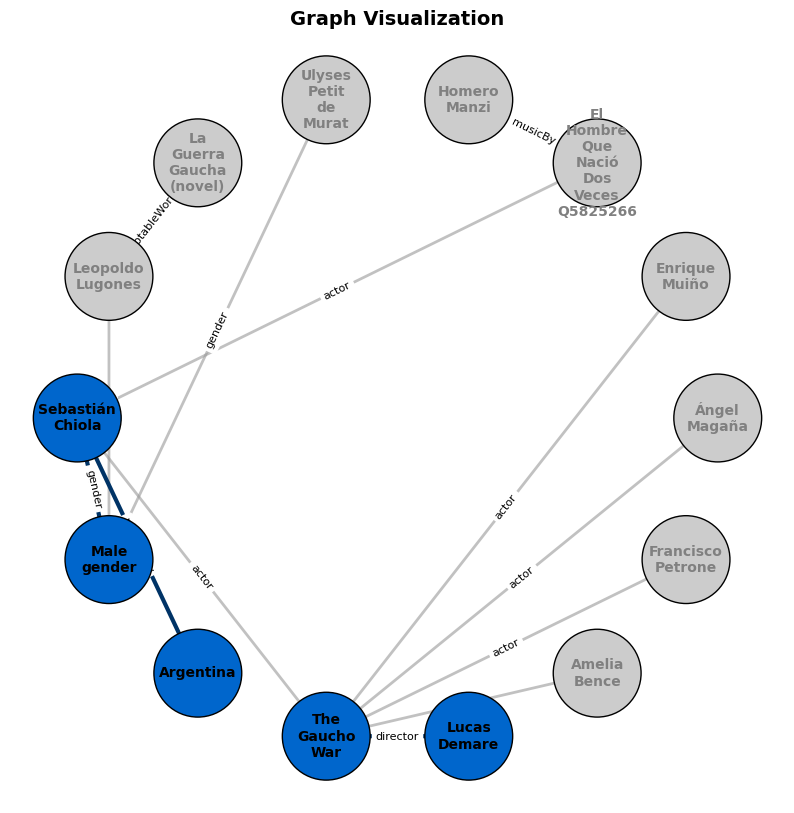

In [45]:
g = create_graph_from_triples(subg)
# plot_graph_with_simplified_labels(g, layout_type='shell', interesting_triples=subg[:3])
plot_graph_with_simplified_labels(g, 
                                  layout_type='shell', 
                                  interesting_triples=subg[:3], 
                                  highlight_node_color="#0066CC",  
                                  highlight_edge_color="#003366", 
                                  default_node_color="#CCCCCC",   
                                  default_edge_color="#999999",   
                                  highlight_text_color="black",    
                                  default_text_color="gray")   



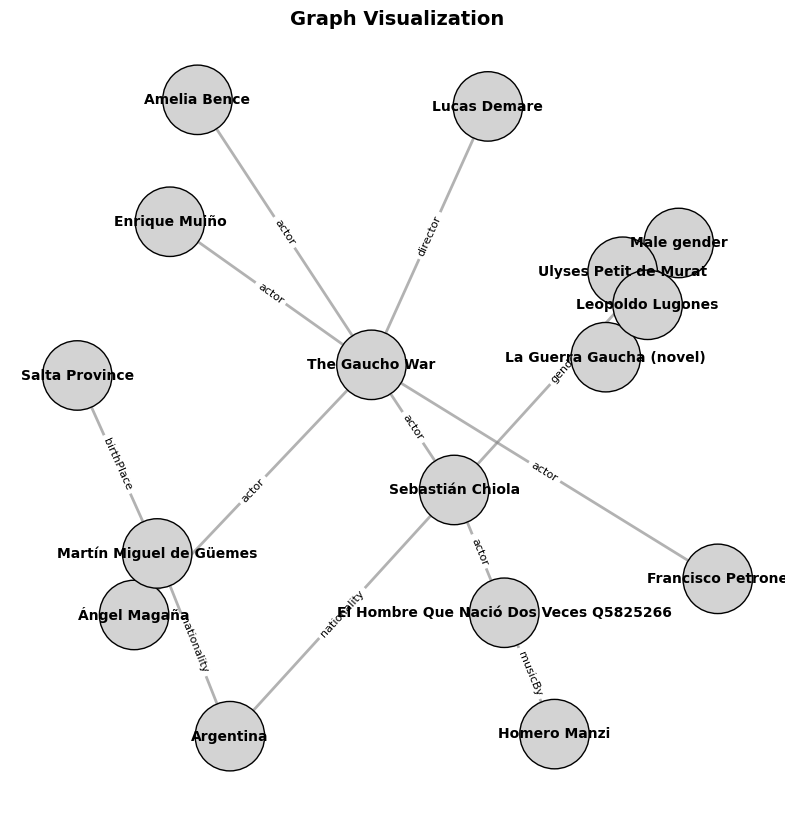

In [18]:
g = create_graph_from_triples(subg)
plot_graph_with_simplified_labels(g, layout_type='spring')

In [16]:
subg = [['http://yago-knowledge.org/resource/Hideki_Kamiya',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Hideki_Kamiya',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Bandai_Namco_Entertainment'],
 ['http://yago-knowledge.org/resource/Stride__u0028_game_engine_u0029_',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Silicon_Studio'],
 ['http://yago-knowledge.org/resource/PlayStation_Vita',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Yuji_Naka',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Yuji_Naka',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Square_Enix'],
 ['http://yago-knowledge.org/resource/Bravely_Default',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Square_Enix'],
 ['http://yago-knowledge.org/resource/Bravely_Default',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Silicon_Studio'],
 ['http://yago-knowledge.org/resource/FromSoftware',
  'http://yago-knowledge.org/resource/ownedBy',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Jun_Yoshino',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Jun_Yoshino',
  'http://schema.org/worksFor',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Sakura_Wars_u003A__So_Long_u002C__My_Love',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Sega'],
 ['http://yago-knowledge.org/resource/Sakura_Wars_u003A__So_Long_u002C__My_Love',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Idea_Factory'],
 ['http://yago-knowledge.org/resource/PlayStation',
  'http://yago-knowledge.org/resource/ownedBy',
  'http://yago-knowledge.org/resource/Sony_Interactive_Entertainment'],
 ['http://yago-knowledge.org/resource/Rise_of_Incarnates',
  'http://schema.org/manufacturer',
  'http://yago-knowledge.org/resource/Bandai_Namco_Entertainment']]

In [19]:
subg = [["http://yago-knowledge.org/resource/China", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Japan"], 
["http://yago-knowledge.org/resource/China", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Kyrgyzstan"], 
["http://yago-knowledge.org/resource/Japan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/China"], 
["http://yago-knowledge.org/resource/Japan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Pacific_Ocean"], 
["http://yago-knowledge.org/resource/Second_Sino-Japanese_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Republic_of_China__u0028_1912_u2013_1949_u0029_"], 
["http://yago-knowledge.org/resource/First_Indochina_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Kingdom_of_Laos"], 
["http://yago-knowledge.org/resource/Kijir\u014d_Nambu", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Japan"], 
["http://yago-knowledge.org/resource/Tomioka_u002C__Fukushima", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Pacific_Ocean"], 
["http://yago-knowledge.org/resource/Vietnam_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Viet_Cong"], 
["http://yago-knowledge.org/resource/Vietnam_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/North_Korea"], 
["http://yago-knowledge.org/resource/Vietnam_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Kingdom_of_Laos"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/China"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/North_Korea"], 
["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Canada"], 
["http://yago-knowledge.org/resource/Pacific_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Canada"], 
["http://yago-knowledge.org/resource/Pacific_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Republic_of_China__u0028_1912_u2013_1949_u0029_"], 
["http://yago-knowledge.org/resource/Kyrgyzstan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/China"], 
["http://yago-knowledge.org/resource/Emperor_Taish\u014d", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Japan"]]



In [152]:
subg = [["http://yago-knowledge.org/resource/Ottoman_Empire", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Byzantine_Empire"], ["http://yago-knowledge.org/resource/Lebanon", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Syria"], ["http://yago-knowledge.org/resource/Byzantine_Empire", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Roman_Empire"], ["http://yago-knowledge.org/resource/Crimean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Ottoman_Empire"], ["http://yago-knowledge.org/resource/Crimean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/British_Empire"], ["http://yago-knowledge.org/resource/Syrian_civil_war", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Bashar_al-Assad"], ["http://yago-knowledge.org/resource/Syria", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Lebanon"], ["http://yago-knowledge.org/resource/Syria", "http://yago-knowledge.org/resource/leader", "http://yago-knowledge.org/resource/Bashar_al-Assad"], ["http://yago-knowledge.org/resource/Syria", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/UNESCO"], ["http://yago-knowledge.org/resource/Syria", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Turkey"], ["http://yago-knowledge.org/resource/Turkey", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Ottoman_Empire"], ["http://yago-knowledge.org/resource/Turkey", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Syria"], ["http://yago-knowledge.org/resource/France", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/UNESCO"]]

In [13]:
subg = [["http://yago-knowledge.org/resource/Betty_Nuthall", "http://schema.org/award", "http://yago-knowledge.org/resource/International_Tennis_Hall_of_Fame"], ["http://yago-knowledge.org/resource/Anna_McCune_Harper", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/John_Van_Ryn", "http://schema.org/award", "http://yago-knowledge.org/resource/International_Tennis_Hall_of_Fame"], ["http://yago-knowledge.org/resource/John_Van_Ryn", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Edith_Cross", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Sarah_Palfrey_Cooke", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/John_Doeg", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Wilmer_Allison", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Marjorie_Morrill", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/George_Lott", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Brodie_Lee", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"]]

In [16]:
subg = [["http://yago-knowledge.org/resource/Cargolux", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Airlines_for_Europe"], ["http://yago-knowledge.org/resource/Air_France", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/SkyTeam"], ["http://yago-knowledge.org/resource/Air_France", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/Air_France_u2013_KLM"], ["http://yago-knowledge.org/resource/Continental_Airlines", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Star_Alliance"], ["http://yago-knowledge.org/resource/China_Airlines", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/SkyTeam"], ["http://yago-knowledge.org/resource/Lufthansa", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Airlines_for_Europe"], ["http://yago-knowledge.org/resource/Lufthansa", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Star_Alliance"], ["http://yago-knowledge.org/resource/Lufthansa", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/International_Air_Transport_Association"], ["http://yago-knowledge.org/resource/TAP_Air_Portugal", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Star_Alliance"], ["http://yago-knowledge.org/resource/Garuda_Indonesia", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/SkyTeam"], ["http://yago-knowledge.org/resource/Air_France_u2013_KLM", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/International_Air_Transport_Association"]]

In [22]:
subg = [["http://yago-knowledge.org/resource/Building__u0028_magazine_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/George_Dewey", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Arleigh_Burke", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Hern\u00e1n_Cort\u00e9s", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Philippines", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Indonesia"], ["http://yago-knowledge.org/resource/Richard_E_u002E__Byrd", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Richard_E_u002E__Byrd", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Philippines"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Quasi-War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Entrance__u0028_album_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/George_Washington", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Artifact__u0028_video_game_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Liam_Neeson", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/War_of_1812", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/War_of_1812", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_Kingdom_of_Great_Britain_and_Ireland"], ["http://yago-knowledge.org/resource/The_Mission__u0028_1986_film_u0029_", "http://schema.org/actor", "http://yago-knowledge.org/resource/Liam_Neeson"], ["http://yago-knowledge.org/resource/Mexican_u2013_American_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Indonesia", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Philippines"], ["http://yago-knowledge.org/resource/Arthur_L_u002E__Willard", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/S_u002E___u0028_Dorst_novel_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/United_States", "http://yago-knowledge.org/resource/officialLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/United_States", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Atlantic_Ocean"], ["http://yago-knowledge.org/resource/Battle_of_Trafalgar", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_Kingdom_of_Great_Britain_and_Ireland"], ["http://yago-knowledge.org/resource/Thomas_Tingey", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Katie_Couric", "http://yago-knowledge.org/resource/notableWork", "http://yago-knowledge.org/resource/Today__u0028_American_TV_program_u0029_"], ["http://yago-knowledge.org/resource/Katie_Couric", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Maine", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Atlantic_Ocean"], ["http://yago-knowledge.org/resource/Fran\u00e7ois-No\u00ebl_Buffet", "http://schema.org/birthPlace", "http://yago-knowledge.org/resource/Lyon"], ["http://yago-knowledge.org/resource/Fran\u00e7ois-No\u00ebl_Buffet", "http://schema.org/nationality", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/South_Korea", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Korea"], ["http://yago-knowledge.org/resource/Trafalgar__u0028_album_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/The_Nineteenth_Century__u0028_periodical_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Monitor__u0028_Mar_Novu_u0029_", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"]]

In [26]:
subg = [["http://yago-knowledge.org/resource/China", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Vietnam"], ["http://yago-knowledge.org/resource/Berlin_Conference", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Georges_Bidault", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Georges_Bidault", "http://schema.org/nationality", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Vietnam", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/China"], ["http://yago-knowledge.org/resource/Germany", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Germany", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Austria"], ["http://yago-knowledge.org/resource/Germany", "http://yago-knowledge.org/resource/capital", "http://yago-knowledge.org/resource/Berlin"], ["http://yago-knowledge.org/resource/Order_of_the_Badge_of_Honour", "http://yago-knowledge.org/resource/conferredBy", "http://yago-knowledge.org/resource/Soviet_Union"], ["http://yago-knowledge.org/resource/South_Korea", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Korea"], ["http://yago-knowledge.org/resource/Vyacheslav_Molotov", "http://schema.org/award", "http://yago-knowledge.org/resource/Order_of_the_Badge_of_Honour"], ["http://yago-knowledge.org/resource/Austria", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Germany"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/China"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/France"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Soviet_Union"], ["http://yago-knowledge.org/resource/Soviet_Union", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Nazi_Germany"], ["http://yago-knowledge.org/resource/World_War_II", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Nazi_Germany"], ["http://yago-knowledge.org/resource/Nazi_Germany", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Soviet_Union"], ["http://yago-knowledge.org/resource/Anthony_Eden", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/John_Foster_Dulles", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/France", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Germany"]]

In [29]:
subg = [["http://yago-knowledge.org/resource/Japan", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Ole_Buttermilk_Sky", "http://schema.org/musicBy", "http://yago-knowledge.org/resource/Hoagy_Carmichael"], ["http://yago-knowledge.org/resource/American_Soldier__u0028_album_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Tom_Ball", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/United_States", "http://yago-knowledge.org/resource/officialLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Cody_Rhodes", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Hoagy_Carmichael", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Tears__u0028_Clean_Bandit_song_u0029_", "http://schema.org/inLanguage", "http://yago-knowledge.org/resource/English_language_generic_instance"], ["http://yago-knowledge.org/resource/Charlie_Brown", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Tommy_Vig", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Tommy_Vig", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Henry_Valdez_Q3866807", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Henry_Valdez_Q3866807", "http://schema.org/birthPlace", "http://yago-knowledge.org/resource/Las_Vegas"], ["http://yago-knowledge.org/resource/Manuel_Cafumana", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/South_Korea", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/China"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/North_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Korean_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Belgium"], ["http://yago-knowledge.org/resource/Lee_Nan-young", "http://schema.org/nationality", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Ailee", "http://schema.org/nationality", "http://yago-knowledge.org/resource/South_Korea"], ["http://yago-knowledge.org/resource/Belgium", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/European_Union"], ["http://yago-knowledge.org/resource/Takuto__u0028_singer_u0029_", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Japan"], ["http://yago-knowledge.org/resource/Hungary", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/European_Union"]]

In [17]:
subg = [["http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Argentina"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/director", "http://yago-knowledge.org/resource/Lucas_Demare"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Amelia_Bence"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Francisco_Petrone"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/\u00c1ngel_Maga\u00f1a"], ["http://yago-knowledge.org/resource/The_Gaucho_War", "http://schema.org/actor", "http://yago-knowledge.org/resource/Enrique_Mui\u00f1o"], ["http://yago-knowledge.org/resource/El_Hombre_Que_Naci\u00f3_Dos_Veces_Q5825266", "http://schema.org/musicBy", "http://yago-knowledge.org/resource/Homero_Manzi"], ["http://yago-knowledge.org/resource/El_Hombre_Que_Naci\u00f3_Dos_Veces_Q5825266", "http://schema.org/actor", "http://yago-knowledge.org/resource/Sebasti\u00e1n_Chiola"], ["http://yago-knowledge.org/resource/Ulyses_Petit_de_Murat", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Mart\u00edn_Miguel_de_G\u00fcemes", "http://schema.org/birthPlace", "http://yago-knowledge.org/resource/Salta_Province"], ["http://yago-knowledge.org/resource/Mart\u00edn_Miguel_de_G\u00fcemes", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Argentina"], ["http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_", "http://schema.org/author", "http://yago-knowledge.org/resource/Leopoldo_Lugones"], ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Leopoldo_Lugones", "http://yago-knowledge.org/resource/notableWork", "http://yago-knowledge.org/resource/La_Guerra_Gaucha__u0028_novel_u0029_"]]

In [38]:
subg = [["http://yago-knowledge.org/resource/Lapu\u0161nik_prison_camp", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/Kosovo_Liberation_Army"], ["http://yago-knowledge.org/resource/Fatmir_Limaj", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Kosovo"], ["http://yago-knowledge.org/resource/Haradin_Bala", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Haradin_Bala", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/Kosovo_Liberation_Army"], ["http://yago-knowledge.org/resource/Kosovo", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Albania"], ["http://yago-knowledge.org/resource/Isak_Musliu", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Fausto_Pocar", "http://schema.org/gender", "http://yago-knowledge.org/resource/Male_gender"], ["http://yago-knowledge.org/resource/Italy", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Slovenia"], ["http://yago-knowledge.org/resource/Albania", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Kosovo"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Italy"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Albania"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Federal_Republic_of_Yugoslavia"], ["http://yago-knowledge.org/resource/Kosovo_War", "http://yago-knowledge.org/resource/participant", "http://yago-knowledge.org/resource/Kosovo_Liberation_Army"], ["http://yago-knowledge.org/resource/XXXTentacion", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/Federal_Republic_of_Yugoslavia", "http://yago-knowledge.org/resource/replaces", "http://yago-knowledge.org/resource/Yugoslavia"], ["http://yago-knowledge.org/resource/Slovenia", "http://schema.org/memberOf", "http://yago-knowledge.org/resource/United_Nations_generic_instance"], ["http://yago-knowledge.org/resource/Slovenia", "http://yago-knowledge.org/resource/neighbors", "http://yago-knowledge.org/resource/Italy"], ["http://yago-knowledge.org/resource/International_Criminal_Tribunal_for_the_former_Yugoslavia", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/United_Nations_generic_instance"]]

In [46]:
subg=[["http://yago-knowledge.org/resource/Bruce_Willis", "http://schema.org/nationality", "http://yago-knowledge.org/resource/Germany"], ["http://yago-knowledge.org/resource/Bruce_Willis", "http://schema.org/nationality", "http://yago-knowledge.org/resource/United_States"], ["http://yago-knowledge.org/resource/The_Player__u0028_1992_film_u0029_", "http://schema.org/actor", "http://yago-knowledge.org/resource/Bruce_Willis"], ["http://yago-knowledge.org/resource/John_McClane", "http://schema.org/performer", "http://yago-knowledge.org/resource/Bruce_Willis"], ["http://yago-knowledge.org/resource/John_McClane", "http://yago-knowledge.org/resource/appearsIn", "http://yago-knowledge.org/resource/Die_Hard_Arcade"], ["http://yago-knowledge.org/resource/Die_Hard_Arcade", "http://schema.org/manufacturer", "http://yago-knowledge.org/resource/Sega_AM1"], ["http://yago-knowledge.org/resource/Sega_AM1", "http://yago-knowledge.org/resource/ownedBy", "http://yago-knowledge.org/resource/Sega"]]

In [42]:
subg = [["http://yago-knowledge.org/resource/Rickettsiaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiales"], ["http://yago-knowledge.org/resource/Rickettsidae_Q20742840", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Methylobacteriaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Hyphomicrobiales"], ["http://yago-knowledge.org/resource/Pelagibacterales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsidae_Q20742840"], ["http://yago-knowledge.org/resource/Gammaproteobacteria", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pseudomonadota"], ["http://yago-knowledge.org/resource/Rickettsiales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Rhodospirillales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Rickettsia", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiaceae"], ["http://yago-knowledge.org/resource/Anaplasmataceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiales"], ["http://yago-knowledge.org/resource/Wolbachia", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Anaplasmataceae"], ["http://yago-knowledge.org/resource/Betaproteobacteria", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pseudomonadota"], ["http://yago-knowledge.org/resource/Hyphomicrobiales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Rhizobium", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rhizobiaceae"], ["http://yago-knowledge.org/resource/Methylobacterium", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Methylobacteriaceae"], ["http://yago-knowledge.org/resource/Brucellaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Hyphomicrobiales"], ["http://yago-knowledge.org/resource/Rhodospirillaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rhodospirillales"], ["http://yago-knowledge.org/resource/Alphaproteobacteria", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pseudomonadota"], ["http://yago-knowledge.org/resource/Candidatus_Pelagibacter_communis", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Pelagibacter_Q18601038"], ["http://yago-knowledge.org/resource/Rhizobiaceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Hyphomicrobiales"], ["http://yago-knowledge.org/resource/Acetobacteraceae", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rhodospirillales"], ["http://yago-knowledge.org/resource/Pelagibacter_Q18601038", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Rickettsiales"], ["http://yago-knowledge.org/resource/Rhodobacterales", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Alphaproteobacteria"], ["http://yago-knowledge.org/resource/Methylobacterium_organophilum", "http://schema.org/parentTaxon", "http://yago-knowledge.org/resource/Methylobacterium"]]

In [47]:
len(subg)

7